# Bayesian Multinomial Logit with Pyro

In [1]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns


# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

/home/dtu/projects/MBMLProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and explore data

In [2]:
df = pd.read_csv('swissmetro.dat', sep='\t')
print(df.head())
print(df.shape)

# Filter: exclude unknown choices and non-commute/business trips
df = df[(df['CHOICE'] != 0) & ((df['PURPOSE'] == 1) | (df['PURPOSE'] == 3))]

print(f"After filtering: {df.shape[0]} rows")

# Select a random subset of 50 IDs
selected_ids = df['ID'].drop_duplicates().sample(n=50)

# Filter the dataset to include only rows with the selected IDs
df = df[df['ID'].isin(selected_ids)]

print(f"With 50 IDs: {df.shape[0]} rows")
print(f"Columns: {df.columns.tolist()}")


   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84       2  
2      52       2  
3      52       2 

In [3]:
# Check available modes and choice distribution
print(f"Unique choices: {sorted(df['CHOICE'].unique())}")
print(f"\nChoice distribution:\n{df['CHOICE'].value_counts().sort_index()}")
print(f"\nMode availability:")
print(f"TRAIN_AV: {df['TRAIN_AV'].sum()} / {len(df)}")
print(f"SM_AV: {df['SM_AV'].sum()} / {len(df)}")
print(f"CAR_AV: {df['CAR_AV'].sum()} / {len(df)}")

Unique choices: [np.int64(1), np.int64(2), np.int64(3)]

Choice distribution:
CHOICE
1     77
2    247
3    126
Name: count, dtype: int64

Mode availability:
TRAIN_AV: 450 / 450
SM_AV: 450 / 450
CAR_AV: 369 / 450


### Prepare data for choice model

Transform to long format (one row per alternative per decision) for the discrete choice model.

In [4]:
# We'll work with travel time and cost
# Modes: 1=Train, 2=SwissMetro, 3=Car

# Standardize attributes (z-score: (x - mean) / std)
df['TRAIN_TT_SCALED'] = (df['TRAIN_TT'] - df['TRAIN_TT'].mean()) / df['TRAIN_TT'].std()
df['TRAIN_CO_SCALED'] = (df['TRAIN_CO'] - df['TRAIN_CO'].mean()) / df['TRAIN_CO'].std()
df['SM_TT_SCALED'] = (df['SM_TT'] - df['SM_TT'].mean()) / df['SM_TT'].std()
df['SM_CO_SCALED'] = (df['SM_CO'] - df['SM_CO'].mean()) / df['SM_CO'].std()
df['CAR_TT_SCALED'] = (df['CAR_TT'] - df['CAR_TT'].mean()) / df['CAR_TT'].std()
df['CAR_CO_SCALED'] = (df['CAR_CO'] - df['CAR_CO'].mean()) / df['CAR_CO'].std()

print(f"Standardized data (mean≈0, std≈1):\n{df[['TRAIN_TT_SCALED', 'TRAIN_CO_SCALED', 'SM_TT_SCALED', 'SM_CO_SCALED', 'CHOICE']].head(10)}")


Standardized data (mean≈0, std≈1):
     TRAIN_TT_SCALED  TRAIN_CO_SCALED  SM_TT_SCALED  SM_CO_SCALED  CHOICE
594        -0.256379        -0.345192     -0.412461     -0.354137       2
595        -0.745722        -0.366606     -0.333378     -0.367203       2
596        -0.256379        -0.366606     -0.227934     -0.362303       2
597        -0.582608        -0.366606     -0.227934     -0.362303       2
598        -0.582608        -0.359111     -0.227934     -0.362303       2
599        -0.745722        -0.359111     -0.227934     -0.362303       2
600        -0.745722        -0.345192     -0.333378     -0.350871       1
601        -0.745722        -0.359111     -0.412461     -0.359037       2
602        -0.582608        -0.345192     -0.227934     -0.341889       2
657        -0.876214        -0.351616     -1.308733     -0.359037       2


### Convert to long format

In [5]:
# Create long-format data for MNL estimation
# Each row observation becomes 3 rows (one per alternative that is available)

long_data = []

# Create a mapping from original indices to sequential obs_id (0, 1, 2, ...)
obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}

for idx, row in df.iterrows():
    obs_id_sequential = obs_id_map[idx]  # Map to sequential ID
    original_id = row['ID']  # Keep track of the individual ID
    
    # Train (alt_id 0)
    if row['TRAIN_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 0,
            'tt': row['TRAIN_TT_SCALED'],
            'co': row['TRAIN_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 1 else 0
        })
    
    # SwissMetro (alt_id 1)
    if row['SM_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 1,
            'tt': row['SM_TT_SCALED'],
            'co': row['SM_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 2 else 0
        })
    
    # Car (alt_id 2)
    if row['CAR_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 2,
            'tt': row['CAR_TT_SCALED'],
            'co': row['CAR_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 3 else 0
        })

long_df = pd.DataFrame(long_data)

# Validate: exactly one choice per obs_id
choices_per_obs = long_df.groupby('obs_id')['choice'].sum()
assert (choices_per_obs == 1).all(), "Error: some observations have != 1 choice"
print("✓ Validation passed: exactly one choice per observation")

print(f"\nLong format shape: {long_df.shape}")
print(f"Number of unique observations: {long_df['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df['ID'].nunique()}")
print(f"Obs_id range: [{long_df['obs_id'].min()}, {long_df['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):")
long_df.head(9)


✓ Validation passed: exactly one choice per observation

Long format shape: (1269, 6)
Number of unique observations: 450
Number of unique individuals: 50
Obs_id range: [0, 449]

Sample (first 9 rows = 3 obs):


,obs_id,ID,alt_id,tt,co,choice
0,0,67.0,0,-0.256379,-0.345192,0
1,0,67.0,1,-0.412461,-0.354137,1
2,0,67.0,2,-0.331817,-0.305832,0
3,1,67.0,0,-0.745722,-0.366606,0
4,1,67.0,1,-0.333378,-0.367203,1
5,1,67.0,2,0.023138,-0.534983,0
6,2,67.0,0,-0.256379,-0.366606,0
7,2,67.0,1,-0.227934,-0.362303,1
8,2,67.0,2,-0.568454,-0.534983,0


In [6]:
# Convert to PyTorch tensors for Pyro
X = torch.tensor(long_df[['tt', 'co']].values, dtype=torch.float32)
Y = torch.tensor(long_df['choice'].values, dtype=torch.int64)
obs_id = torch.tensor(long_df['obs_id'].values, dtype=torch.int64)
alt_id = torch.tensor(long_df['alt_id'].values, dtype=torch.int64)

### Define Bayesian Multinomial Logit Model in Pyro

In [7]:
def model(X, Y, obs_id, alt_id, n_alts=3):
    """
    Bayesian Multinomial Logit Model in Pyro
    
    Parameters:
    - X: (N_alts, n_features) alternative attributes in long format
    - Y: (N_alts,) choice indicator in long format (1 if chosen, 0 otherwise)
    - obs_id: observation ID for grouping alternatives
    - alt_id: alternative ID (0, 1, 2)
    - n_alts: number of alternatives (3: Train, SwissMetro, Car)
    """
    n_obs = obs_id.max().item() + 1
    n_features = X.shape[1]
    
    # Priors on coefficients: explicitly expand to vector
    beta = pyro.sample('beta', dist.Normal(0, 1).expand([n_features]).to_event(1))
    
    # Alternative-specific constants: fix first to 0 for identification
    # Sample only for alternatives 1 and 2
    asc_zero = pyro.sample('asc', dist.Normal(0, 1).expand([n_alts - 1]).to_event(1))
    asc = torch.cat([torch.zeros(1, dtype=asc_zero.dtype, device=asc_zero.device), asc_zero])
    
    # Utility for each alternative: V_i = X_i @ beta + ASC_i (long format)
    V = X @ beta + asc[alt_id]
    
    # Convert to wide format: (n_obs, n_alts)
    V_wide = torch.full((n_obs, n_alts), float('-inf'))
    V_wide[obs_id, alt_id] = V
    
    # Convert choice from long to wide format
    Y_wide = torch.zeros(n_obs, dtype=torch.int64)
    chosen_mask = Y == 1
    Y_wide[obs_id[chosen_mask]] = alt_id[chosen_mask]
    
    # Likelihood: categorical (multinomial logit)
    with pyro.plate('obs', n_obs):
        pyro.sample('choice', dist.Categorical(logits=V_wide), obs=Y_wide)


### Run MCMC inference

In [8]:
# Use NUTS sampler for efficient HMC-based inference
nuts_kernel = NUTS(model, adapt_step_size=True)

mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=200, num_chains=1)

mcmc.run(X, Y, obs_id, alt_id, n_alts=3)

Sample: 100%|██████████| 2200/2200 [00:30, 72.20it/s, step size=4.97e-01, acc. prob=0.923]


### Examine results and check out plots

In [9]:
# Get posterior samples
posterior_samples = mcmc.get_samples()

print("Posterior means:")
for key, val in posterior_samples.items():
    print(f"\n{key}:")
    print(f"  Mean: {val.mean(dim=0)}")
    print(f"  Std: {val.std(dim=0)}")

Posterior means:

asc:
  Mean: tensor([1.1590, 1.0045])
  Std: tensor([0.1282, 0.1534])

beta:
  Mean: tensor([-0.6421, -0.1491])
  Std: tensor([0.1278, 0.1067])


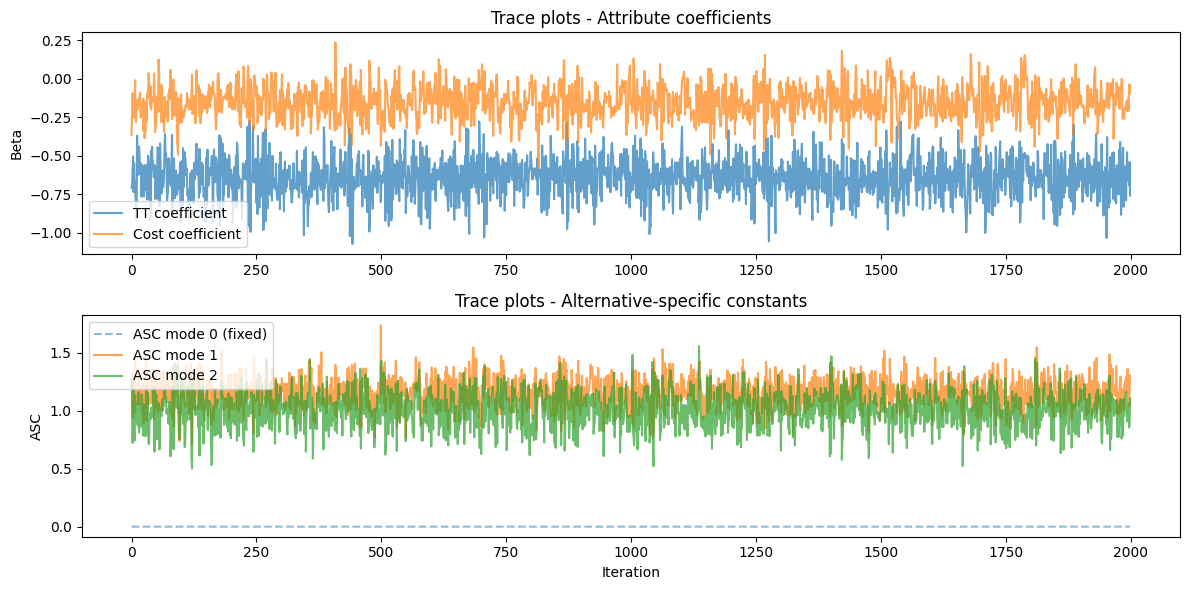

In [10]:
# Plot trace plots for diagnostics
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Beta (attribute effects)
beta_samples = posterior_samples['beta']
axes[0].plot(beta_samples[:, 0], label='TT coefficient', alpha=0.7)
axes[0].plot(beta_samples[:, 1], label='Cost coefficient', alpha=0.7)
axes[0].set_ylabel('Beta')
axes[0].legend()
axes[0].set_title('Trace plots - Attribute coefficients')

# ASC (alternative-specific constants) - only 2 sampled (first fixed to 0)
asc_samples = posterior_samples['asc']
axes[1].plot(torch.zeros_like(asc_samples[:, 0]), label='ASC mode 0 (fixed)', alpha=0.5, linestyle='--')
for i in range(asc_samples.shape[1]):
    axes[1].plot(asc_samples[:, i], label=f'ASC mode {i+1}', alpha=0.7)
axes[1].set_ylabel('ASC')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].set_title('Trace plots - Alternative-specific constants')

plt.tight_layout()
plt.show()

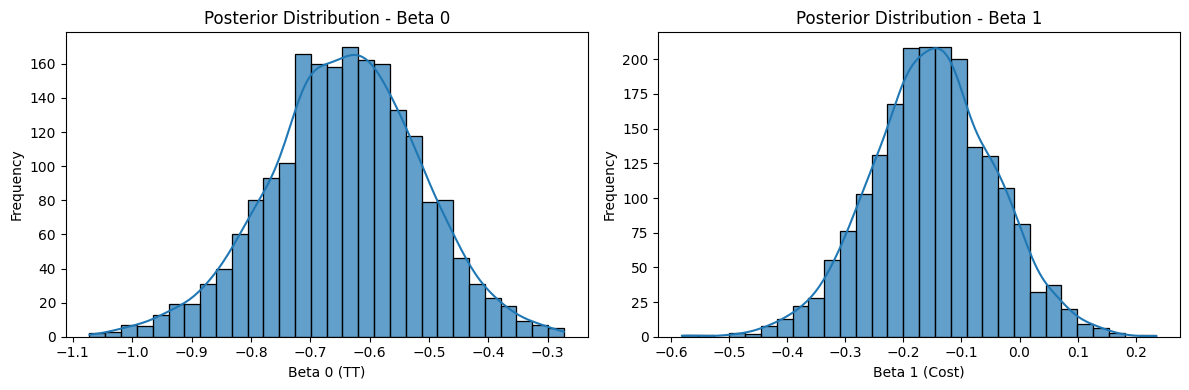

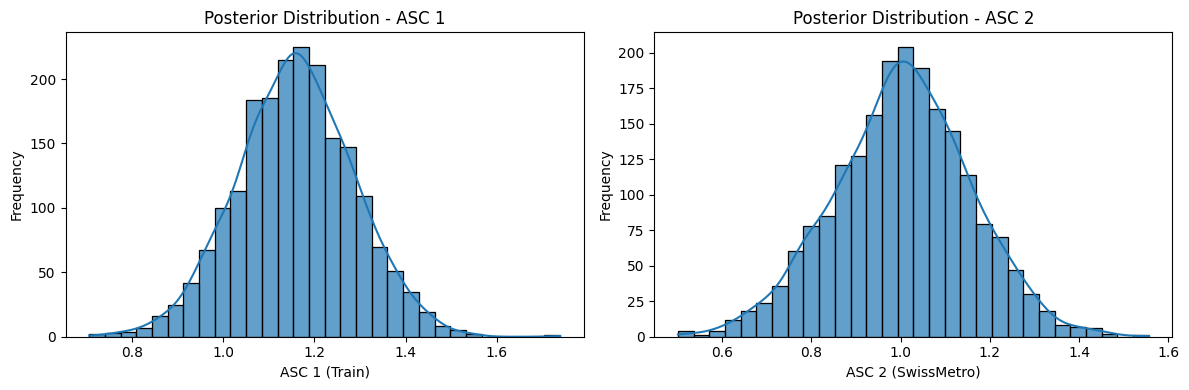

In [11]:
# Plot posterior distributions for beta (attribute coefficients)
fig, axes = plt.subplots(1, X.shape[1], figsize=(12, 4))

beta_samples = posterior_samples['beta'].detach().numpy()
for d in range(X.shape[1]):
    sns.histplot(beta_samples[:, d], bins=30, kde=True, alpha=0.7, ax=axes[d])
    axes[d].set_xlabel(f'Beta {d} ({"TT" if d==0 else "Cost"})')
    axes[d].set_ylabel('Frequency')
    axes[d].set_title(f'Posterior Distribution - Beta {d}')

plt.tight_layout()
plt.show()

# Plot posterior distributions for ASC (alternative-specific constants)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

asc_samples = posterior_samples['asc'].detach().numpy()
mode_names = ['Train', 'SwissMetro']

for c in range(asc_samples.shape[1]):
    sns.histplot(asc_samples[:, c], bins=30, kde=True, alpha=0.7, ax=axes[c])
    axes[c].set_xlabel(f'ASC {c+1} ({mode_names[c]})')
    axes[c].set_ylabel('Frequency')
    axes[c].set_title(f'Posterior Distribution - ASC {c+1}')

plt.tight_layout()
plt.show()

---
## Mixture of Logits — K latent classes, uniform weights

Extension of MNL with K sets of (β, ASC) parameters, marginalising over classes with equal weight 1/K per scenario.

In [12]:
n_obs_lccm = int(obs_id.max().item()) + 1

Y_wide = torch.zeros(n_obs_lccm, dtype=torch.int64)
chosen_mask = Y == 1
Y_wide[obs_id[chosen_mask]] = alt_id[chosen_mask]

print(f"Observations : {n_obs_lccm}")
print(f"Choice counts: {Y_wide.bincount()}")

Observations : 450
Choice counts: tensor([ 77, 247, 126])


In [13]:
def model_mixture(X, obs_id, alt_id, Y_wide, n_alts=3, K=2):
    """Mixture of Logits: K classes with uniform mixing weights, marginalised per scenario."""
    n_obs      = Y_wide.shape[0]
    n_features = X.shape[1]

    beta    = pyro.sample('beta', dist.Normal(0., 1.).expand([K, n_features]).to_event(2))
    asc_raw = pyro.sample('asc',  dist.Normal(0., 1.).expand([K, n_alts - 1]).to_event(2))
    asc_full = torch.cat([torch.zeros(K, 1), asc_raw], dim=1)  # Train ASC fixed to 0

    log_w = -torch.log(torch.tensor(float(K)))

    log_lik_list = []
    for k in range(K):
        V_k      = X @ beta[k] + asc_full[k][alt_id]
        V_wide_k = torch.full((n_obs, n_alts), -1e9)
        V_wide_k[obs_id, alt_id] = V_k
        log_lik_list.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide))

    log_lik      = torch.stack(log_lik_list, dim=1)         # [n_obs, K]
    log_marginal = torch.logsumexp(log_w + log_lik, dim=-1) # [n_obs]

    with pyro.plate('obs', n_obs):
        pyro.factor('loglik', log_marginal)

In [14]:
pyro.clear_param_store()

K = 2
nuts_kernel = NUTS(model_mixture, adapt_step_size=True)
mcmc_mix = MCMC(nuts_kernel, num_samples=500, warmup_steps=300, num_chains=1)
mcmc_mix.run(X, obs_id, alt_id, Y_wide, n_alts=3, K=K)

Sample: 100%|██████████| 800/800 [00:17, 45.44it/s, step size=4.84e-01, acc. prob=0.902] 


### Inspect posterior — label-switching correction

Classes are exchangeable, so we sort by β_TT to ensure class 0 is always the more time-sensitive segment.

                                    mean      std
--------------------------------------------------

  Class 0:
    beta_TT      -1.769    0.396
    beta_CO       0.297    0.372
    ASC_SM       -1.775    0.881
    ASC_Car       1.926    0.417

  Class 1:
    beta_TT      -0.279    0.535
    beta_CO      -0.420    0.488
    ASC_SM        3.404    0.773
    ASC_Car      -0.770    0.880


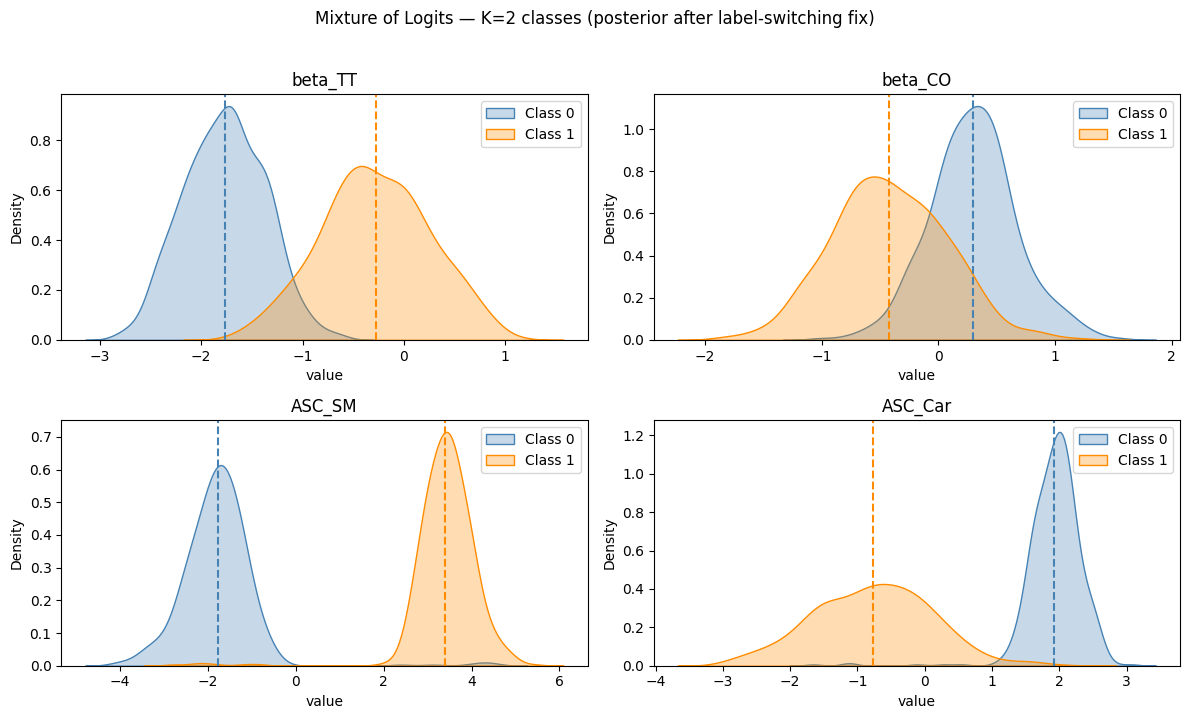

In [15]:
samples = mcmc_mix.get_samples()

beta_s = samples['beta']  # [S, K, 2]
asc_s  = samples['asc']   # [S, K, 2]

# sort by beta_TT so class 0 is always the more time-sensitive segment
order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}:")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes   = axes.ravel()
colors = ['steelblue', 'darkorange']

params = [
    ('beta_TT', [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO', [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',  [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car', [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes, params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

plt.suptitle(f'Mixture of Logits — K={K} classes (posterior after label-switching fix)', y=1.02)
plt.tight_layout()
plt.show()

---
## Mixture of Logits with SVI — full dataset

Switch from MCMC to Stochastic Variational Inference (SVI) with AutoNormal guide to scale to all 752 individuals.

In [16]:
df_full = pd.read_csv('swissmetro.dat', sep='\t')
df_full = df_full[
    (df_full['CHOICE'] != 0) &
    ((df_full['PURPOSE'] == 1) | (df_full['PURPOSE'] == 3))
]
print(f"Full dataset: {df_full['ID'].nunique()} individuals, {len(df_full)} scenarios")

for raw_col, scaled_col in [
    ('TRAIN_TT', 'TRAIN_TT_S'), ('TRAIN_CO', 'TRAIN_CO_S'),
    ('SM_TT',    'SM_TT_S'),    ('SM_CO',    'SM_CO_S'),
    ('CAR_TT',   'CAR_TT_S'),   ('CAR_CO',   'CAR_CO_S'),
]:
    mu  = df_full[raw_col].mean()
    sig = df_full[raw_col].std()
    df_full[scaled_col] = (df_full[raw_col] - mu) / sig

long_rows = []
obs_map   = {orig: new for new, orig in enumerate(df_full.index.unique())}

alt_cfg = [
    (0, 'TRAIN_AV', 'TRAIN_TT_S', 'TRAIN_CO_S', 1),
    (1, 'SM_AV',    'SM_TT_S',    'SM_CO_S',    2),
    (2, 'CAR_AV',   'CAR_TT_S',   'CAR_CO_S',   3),
]
for idx, row in df_full.iterrows():
    oid = obs_map[idx]
    for alt, av, tt_col, co_col, choice_val in alt_cfg:
        if row[av] == 1:
            long_rows.append({
                'obs_id': oid, 'alt_id': alt,
                'tt': row[tt_col], 'co': row[co_col],
                'choice': 1 if row['CHOICE'] == choice_val else 0,
            })

long_full = pd.DataFrame(long_rows)
assert (long_full.groupby('obs_id')['choice'].sum() == 1).all(), "choice validation failed"

X_f      = torch.tensor(long_full[['tt', 'co']].values, dtype=torch.float32)
Y_f      = torch.tensor(long_full['choice'].values,      dtype=torch.int64)
obs_id_f = torch.tensor(long_full['obs_id'].values,      dtype=torch.int64)
alt_id_f = torch.tensor(long_full['alt_id'].values,      dtype=torch.int64)

n_obs_f    = int(obs_id_f.max().item()) + 1
Y_wide_f   = torch.zeros(n_obs_f, dtype=torch.int64)
mask_f     = Y_f == 1
Y_wide_f[obs_id_f[mask_f]] = alt_id_f[mask_f]

print(f"Observations : {n_obs_f}")
print(f"Long rows    : {len(long_full)}")
print(f"Choice counts (Train / SM / Car): {Y_wide_f.bincount().tolist()}")

Full dataset: 752 individuals, 6768 scenarios
Observations : 6768
Long rows    : 19143
Choice counts (Train / SM / Car): [908, 4090, 1770]


[step    0]  ELBO loss: 6,999.8
[step  500]  ELBO loss: 5,438.6
[step 1000]  ELBO loss: 5,438.2
[step 1500]  ELBO loss: 5,441.2
[step 2000]  ELBO loss: 5,439.9
[step 2500]  ELBO loss: 5,438.8
[step 2999]  ELBO loss: 5,437.1


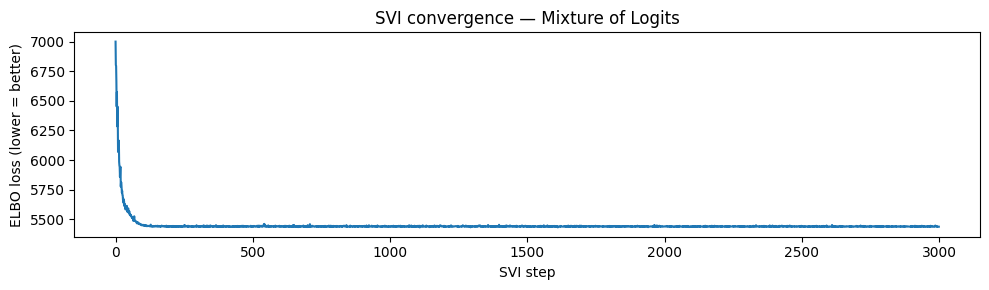

In [17]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal

pyro.clear_param_store()
pyro.set_rng_seed(42)

K = 2

guide     = AutoNormal(model_mixture)
optimizer = pyro.optim.ClippedAdam({"lr": 0.05, "lrd": 0.9995})
svi       = SVI(model_mixture, guide, optimizer, loss=Trace_ELBO())

n_steps = 3000
losses  = []

for step in range(n_steps):
    loss = svi.step(X_f, obs_id_f, alt_id_f, Y_wide_f, n_alts=3, K=K)
    losses.append(loss)
    if step % 500 == 0 or step == n_steps - 1:
        print(f"[step {step:4d}]  ELBO loss: {loss:,.1f}")

plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel('SVI step')
plt.ylabel('ELBO loss (lower = better)')
plt.title('SVI convergence — Mixture of Logits')
plt.tight_layout()
plt.show()

                                    mean      std
--------------------------------------------------

  Class 0:
    beta_TT      -2.055    0.072
    beta_CO       0.374    0.056
    ASC_SM        0.021    0.067
    ASC_Car       1.846    0.055

  Class 1:
    beta_TT       0.495    0.089
    beta_CO      -1.084    0.135
    ASC_SM        3.508    0.167
    ASC_Car      -2.904    0.435


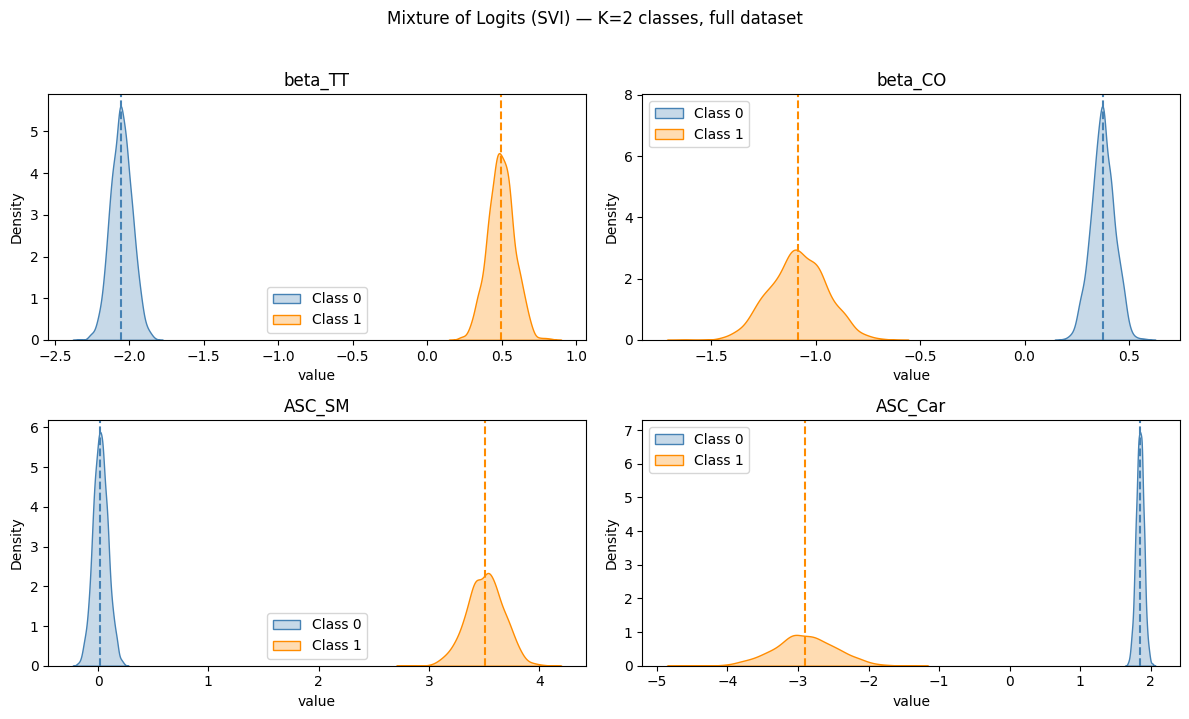

In [18]:
# Predictive() clashes with AutoNormal's K-class dimension, so we sample the guide directly
with torch.no_grad():
    beta_list, asc_list = [], []
    for _ in range(2000):
        s = guide(X_f, obs_id_f, alt_id_f, Y_wide_f, n_alts=3, K=K)
        beta_list.append(s['beta'])
        asc_list.append(s['asc'])

beta_s = torch.stack(beta_list)  # [2000, K, 2]
asc_s  = torch.stack(asc_list)   # [2000, K, 2]

order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}:")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes   = axes.ravel()
colors = ['steelblue', 'darkorange']

params = [
    ('beta_TT', [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO', [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',  [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car', [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes, params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

plt.suptitle(f'Mixture of Logits (SVI) — K={K} classes, full dataset', y=1.02)
plt.tight_layout()
plt.show()

---
## LCCM — Person-level Latent Class with Learnable Mixing Weights

Class membership is assigned at the person level by summing all 9 scenario log-likelihoods per person before the logsumexp, with mixing weights π learned via a Dirichlet prior.

In [19]:
person_seq  = {pid: i for i, pid in enumerate(df_full['ID'].unique())}
rev_obs_map = {v: k for k, v in obs_map.items()}

person_obs_id_f = torch.tensor(
    [person_seq[df_full.loc[rev_obs_map[t], 'ID']] for t in range(n_obs_f)],
    dtype=torch.int64
)

n_persons_f = int(person_obs_id_f.max().item()) + 1
print(f"Persons: {n_persons_f},  Scenarios: {n_obs_f},  Ratio: {n_obs_f/n_persons_f:.1f}")

assert (person_obs_id_f.bincount() == 9).all()
print("✓ All 752 persons have exactly 9 scenarios")

Persons: 752,  Scenarios: 6768,  Ratio: 9.0
✓ All 752 persons have exactly 9 scenarios


In [20]:
def model_lccm(X, obs_id, alt_id, Y_wide, person_obs_id, n_alts=3, K=2):
    """Bayesian LCCM (Sfeir et al. 2021, Eq. 6-9): person-level class membership, learnable π."""
    n_persons   = int(person_obs_id.max().item()) + 1
    n_scenarios = Y_wide.shape[0]
    n_features  = X.shape[1]

    pi    = pyro.sample('pi', dist.Dirichlet(torch.ones(K)))
    log_w = pi.log()

    beta    = pyro.sample('beta', dist.Normal(0., 1.).expand([K, n_features]).to_event(2))
    asc_raw = pyro.sample('asc',  dist.Normal(0., 1.).expand([K, n_alts - 1]).to_event(2))
    asc_full = torch.cat([torch.zeros(K, 1), asc_raw], dim=1)  # Train ASC fixed to 0

    scen_ll_list = []
    for k in range(K):
        V_k      = X @ beta[k] + asc_full[k][alt_id]
        V_wide_k = torch.full((n_scenarios, n_alts), -1e9)
        V_wide_k[obs_id, alt_id] = V_k
        scen_ll_list.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide))

    scen_ll = torch.stack(scen_ll_list, dim=1)  # [n_scenarios, K]

    # sum each person's 9 scenario log-probs before the logsumexp (person-level membership)
    person_ll = torch.zeros(n_persons, K)
    person_ll.scatter_add_(0, person_obs_id.unsqueeze(1).expand_as(scen_ll), scen_ll)

    log_marginal = torch.logsumexp(log_w + person_ll, dim=-1)  # [n_persons]

    with pyro.plate('persons', n_persons):
        pyro.factor('loglik', log_marginal)

[step    0]  ELBO loss: 6,782.1
[step  500]  ELBO loss: 4,829.2
[step 1000]  ELBO loss: 4,824.1
[step 1500]  ELBO loss: 4,823.1
[step 2000]  ELBO loss: 4,826.0
[step 2500]  ELBO loss: 4,824.4
[step 2999]  ELBO loss: 4,823.3


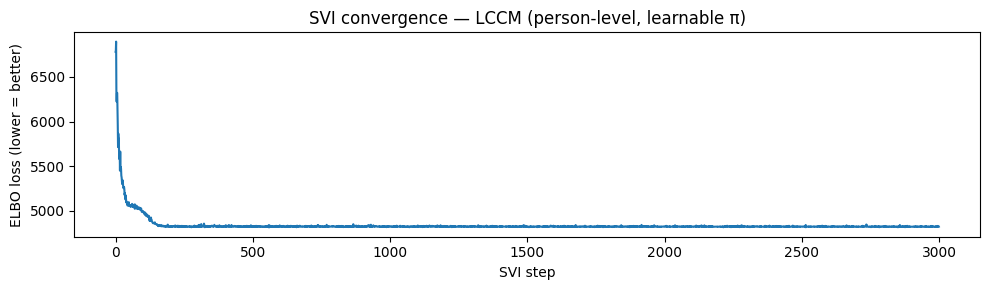

In [21]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal

pyro.clear_param_store()
pyro.set_rng_seed(42)
K = 2

guide_lccm = AutoNormal(model_lccm)
optimizer  = pyro.optim.ClippedAdam({"lr": 0.05, "lrd": 0.9995})
svi_lccm   = SVI(model_lccm, guide_lccm, optimizer, loss=Trace_ELBO())

n_steps = 3000
losses_lccm = []

for step in range(n_steps):
    loss = svi_lccm.step(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K)
    losses_lccm.append(loss)
    if step % 500 == 0 or step == n_steps - 1:
        print(f"[step {step:4d}]  ELBO loss: {loss:,.1f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_lccm)
plt.xlabel('SVI step')
plt.ylabel('ELBO loss (lower = better)')
plt.title('SVI convergence — LCCM (person-level, learnable π)')
plt.tight_layout()
plt.show()


                                    mean      std
--------------------------------------------------

  Class 0  (π: 0.704 ± 0.017):
    beta_TT      -1.035    0.058
    beta_CO      -0.538    0.041
    ASC_SM        3.557    0.034
    ASC_Car       3.739    0.042

  Class 1  (π: 0.296 ± 0.017):
    beta_TT       0.111    0.049
    beta_CO      -0.156    0.061
    ASC_SM        0.194    0.068
    ASC_Car      -2.262    0.163


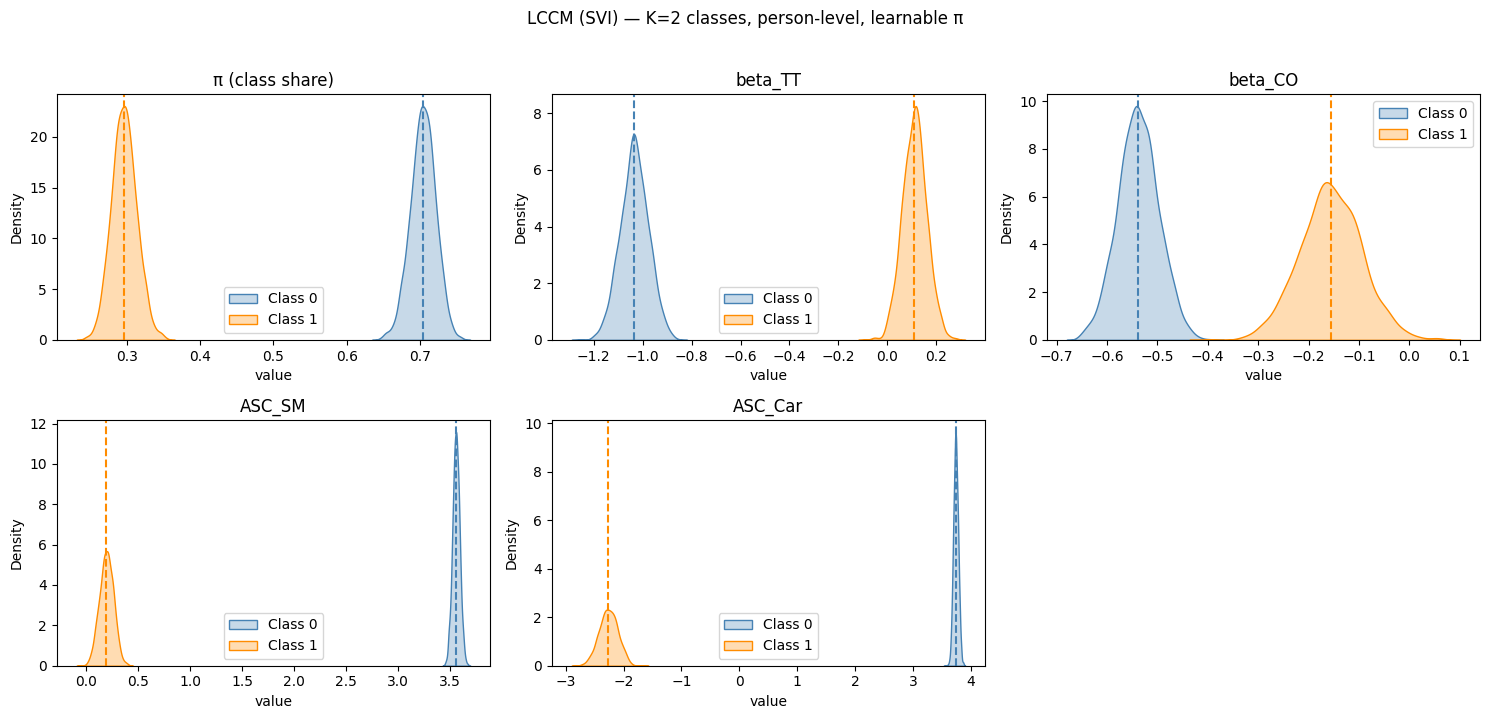

In [22]:
with torch.no_grad():
    pi_list, beta_list, asc_list = [], [], []
    for _ in range(2000):
        s = guide_lccm(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K)
        pi_list.append(s['pi'])
        beta_list.append(s['beta'])
        asc_list.append(s['asc'])

pi_s   = torch.stack(pi_list)    # [2000, K]
beta_s = torch.stack(beta_list)  # [2000, K, 2]
asc_s  = torch.stack(asc_list)   # [2000, K, 2]

order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))
pi_s   = torch.gather(pi_s,   1, order)

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}  (π: {pi_s[:, k].mean():.3f} ± {pi_s[:, k].std():.3f}):")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
colors = ['steelblue', 'darkorange']

params = [
    ('π (class share)',  [pi_s[:,   k].numpy() for k in range(K)]),
    ('beta_TT',          [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO',          [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',           [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car',          [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes.ravel()[:5], params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

axes.ravel()[-1].set_visible(False)

plt.suptitle(f'LCCM (SVI) — K={K} classes, person-level, learnable π', y=1.02)
plt.tight_layout()
plt.show()